# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

Автор: Екатерина Мирау

Дата: 10.05.2026

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# импорт библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

# загрузка исторических данных
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

# вывод первых 5 строк
display(sessions_history.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
# считаем количество уникальных сессий для каждого пользователя
sessions_per_user = (
    sessions_history.groupby('user_id')['session_id'].nunique().sort_values(ascending=False))

# пользователь с максимальным количеством сессий
top_user = sessions_per_user.index[0]

print('ID пользователя:', top_user)
print('Количество сессий:', sessions_per_user.iloc[0])

# выводим все строки по этому пользователю
display(
    sessions_history[sessions_history['user_id'] == top_user].sort_values('session_number'))

ID пользователя: 10E0DEFC1ABDBBE0
Количество сессий: 10


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [3]:
# агрегируем данные по дням
daily_stats = (
    sessions_history.groupby('session_date').agg(total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', 'sum')).reset_index())

# считаем долю зарегистрированных пользователей
daily_stats['registration_share'] = (daily_stats['registered_users'] / daily_stats['total_users'])

display(daily_stats.head())

,session_date,total_users,registered_users,registration_share
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


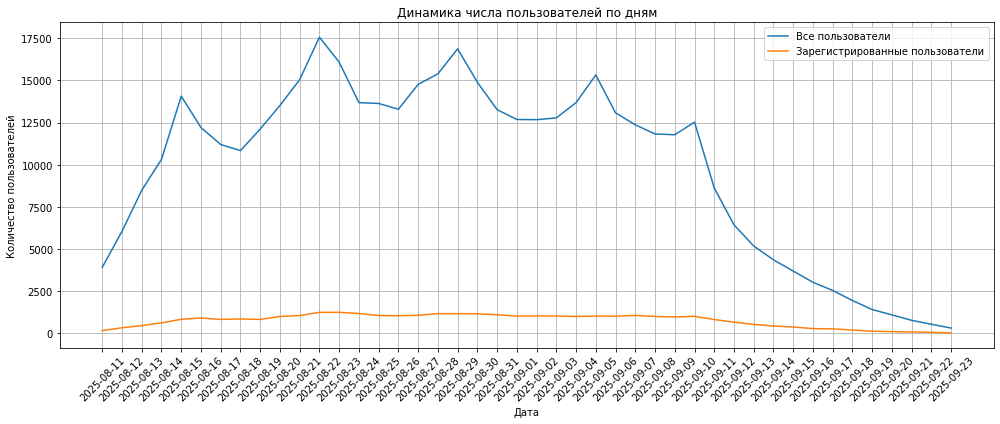

In [4]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_stats['session_date'],
    daily_stats['total_users'],
    label='Все пользователи'
)

plt.plot(
    daily_stats['session_date'],
    daily_stats['registered_users'],
    label='Зарегистрированные пользователи'
)

plt.title('Динамика числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout() 
plt.show()

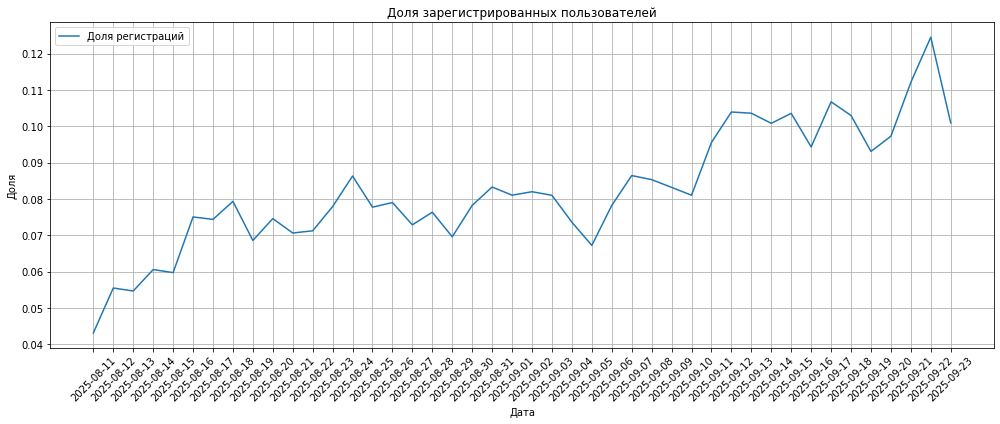

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_stats['session_date'],
    daily_stats['registration_share']
)

plt.title('Доля зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(['Доля регистраций'])

plt.tight_layout()
plt.show()

Вывод по разделу 1.3

За период наблюдения общее число активных пользователей стабильно росло — с ~4 000 в начале до ~14 000 в конце периода. Приложение активно набирает аудиторию.

Доля зарегистрированных пользователей держится в диапазоне 5–7% без выраженного роста. Простой прирост трафика не конвертируется в регистрации сам по себе — нужно улучшать качество пользовательского опыта. Именно это и является целью нашего A/B-теста с новым алгоритмом рекомендаций.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [6]:
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [7]:
pages_distribution = (
    first_sessions['page_counter']
    .value_counts()
    .sort_index()
    .reset_index()
)

pages_distribution.columns = ['page_counter', 'sessions_count']

display(pages_distribution.head())

,page_counter,sessions_count
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075


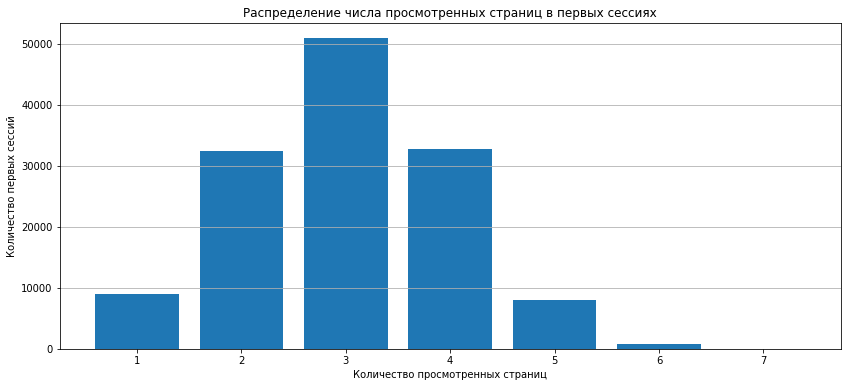

In [8]:
plt.figure(figsize=(14,6))

plt.bar(
    pages_distribution['page_counter'],
    pages_distribution['sessions_count']
)

plt.title('Распределение числа просмотренных страниц в первых сессиях')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество первых сессий')

plt.grid(axis='y')

plt.show()

Вывод по разделу 1.4

Распределение числа просмотренных страниц в первых сессиях близко к нормальному с пиком на 3 страницах. Большинство пользователей просматривает 2–4 страницы; сессии с 1 или 5+ страницами редки.

Порог «успешной» сессии в 4 страницы попадает в правую часть распределения — в эту категорию входит примерно треть пользователей. Это разумный и измеримый критерий вовлечённости для прокси-метрики.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [9]:
sessions_history['good_session'] = (
    sessions_history['page_counter'] >= 4
).astype(int)

In [10]:
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [11]:
daily_good_sessions = (
    first_sessions.groupby('session_date')
    .agg(
        good_share=('good_session', 'mean'),
        total_first_sessions=('good_session', 'count')
    )
    .reset_index()
)

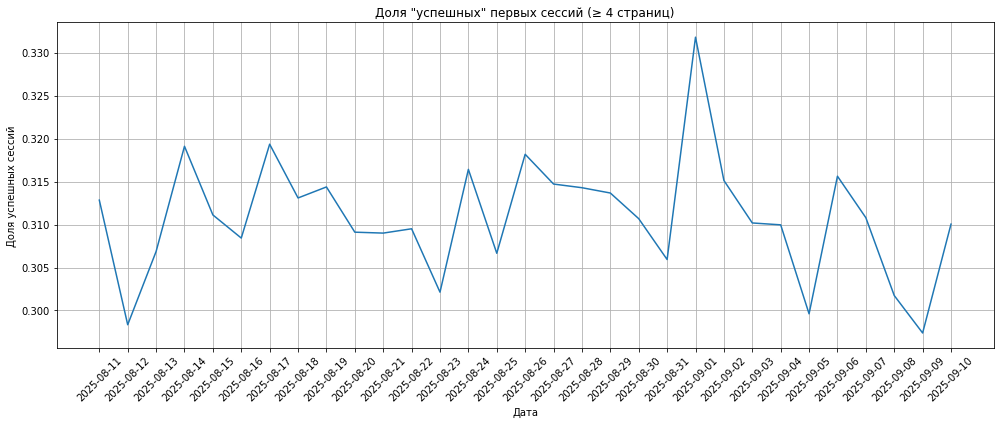

In [12]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_good_sessions['session_date'],
    daily_good_sessions['good_share']
)

plt.title('Доля "успешных" первых сессий (≥ 4 страниц)')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

Вывод по разделу 1.5

Доля «успешных» первых сессий (≥ 4 просмотренных страниц) стабильна на уровне 30–32% на протяжении всего периода наблюдения — без выраженного тренда.

Стабильность метрики подтверждает её надёжность как baseline. Именно значение ~30% используется в расчёте размера выборки (p = 0.3). Любое значимое отклонение в тестовой группе можно будет уверенно атрибутировать эффекту нового алгоритма, а не внешним факторам.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [13]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # 3% от базового уровня доли (0.3 * 0.03 = 0.009)
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


Вывод по разделу 2.1

При параметрах теста (α = 0.05, MDE = 3% от базового уровня доли, базовый уровень метрики p = 0.3, мощность = 0.8) расчётный размер выборки составляет 41 040 пользователей на каждую группу.

#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [14]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = (
    sessions_history.groupby('session_date')['user_id'].nunique().mean())

# Рассчитываем длительность теста: sample_size * 2, так как в тесте две группы
test_duration = ceil((sample_size * 2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


Вывод по разделу 2.2

Среднесуточное число активных пользователей — ~9 900 человек. С учётом двух групп суммарно нужно набрать 82 080 пользователей. При таком трафике теоретически достаточно 9 дней для набора нужного объёма данных.
На практике тест рекомендуется проводить не менее 7–14 дней, чтобы учесть недельную сезонность и разные паттерны поведения аудитории. Фактический период теста (~20 дней) полностью удовлетворяет этому требованию.

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [15]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

display(sessions_test_part.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [16]:
group_counts = (sessions_test_part.groupby('test_group')['user_id'].nunique())

group_counts

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [17]:
A = group_counts['A']
B = group_counts['B']

P = 100 * abs(A - B) / A

print(f"Группа A: {A}")
print(f"Группа B: {B}")
print(f"Процентное отклонение: {P:.2f}%")

Группа A: 1477
Группа B: 1466
Процентное отклонение: 0.74%


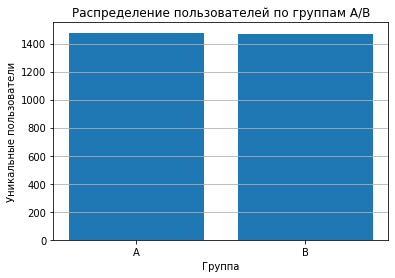

In [18]:
plt.figure(figsize=(6,4))

plt.bar(group_counts.index, group_counts.values)

plt.title('Распределение пользователей по группам A/B')
plt.xlabel('Группа')
plt.ylabel('Уникальные пользователи')
plt.grid(axis='y')

plt.show()

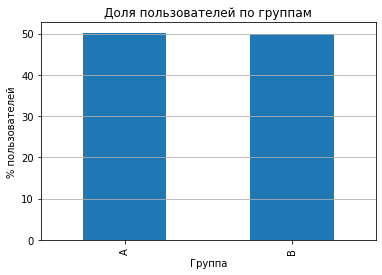

In [19]:
(group_counts / group_counts.sum() * 100).plot(kind='bar')

plt.title('Доля пользователей по группам')
plt.ylabel('% пользователей')
plt.xlabel('Группа')
plt.grid(axis='y')
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [20]:
user_groups = sessions_test_part.groupby('user_id')['test_group'].nunique()

conflicted_users = (user_groups > 1).sum()

print("Пользователи в обеих группах:", conflicted_users)

Пользователи в обеих группах: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [21]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

In [22]:
device_share_A = (
    group_A.drop_duplicates('user_id')['device']
    .value_counts(normalize=True)
    .sort_index()
)

In [23]:
device_share_B = (
    group_B.drop_duplicates('user_id')['device']
    .value_counts(normalize=True)
    .sort_index()
)

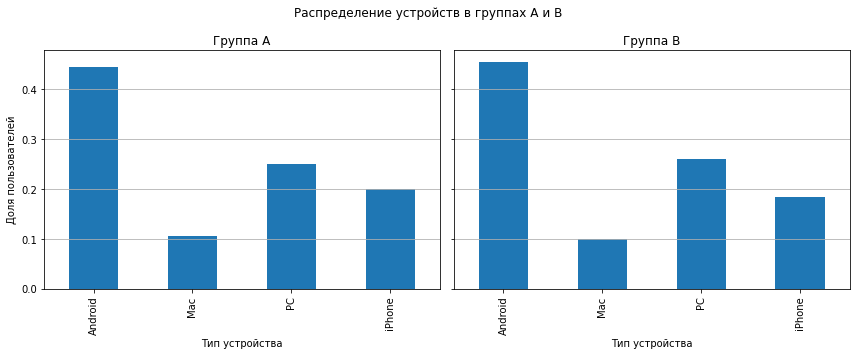

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

device_share_A.plot(kind='bar', ax=axes[0], title='Группа A')
axes[0].set_xlabel('Тип устройства')
axes[0].set_ylabel('Доля пользователей')
axes[0].grid(axis='y')

device_share_B.plot(kind='bar', ax=axes[1], title='Группа B')
axes[1].set_xlabel('Тип устройства')
axes[1].grid(axis='y')

plt.suptitle('Распределение устройств в группах A и B')
plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [25]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

In [26]:
region_share_A = (
    group_A.drop_duplicates('user_id')['region']
    .value_counts(normalize=True)
    .sort_values()
)

region_share_B = (
    group_B.drop_duplicates('user_id')['region']
    .value_counts(normalize=True)
    .sort_values()
)

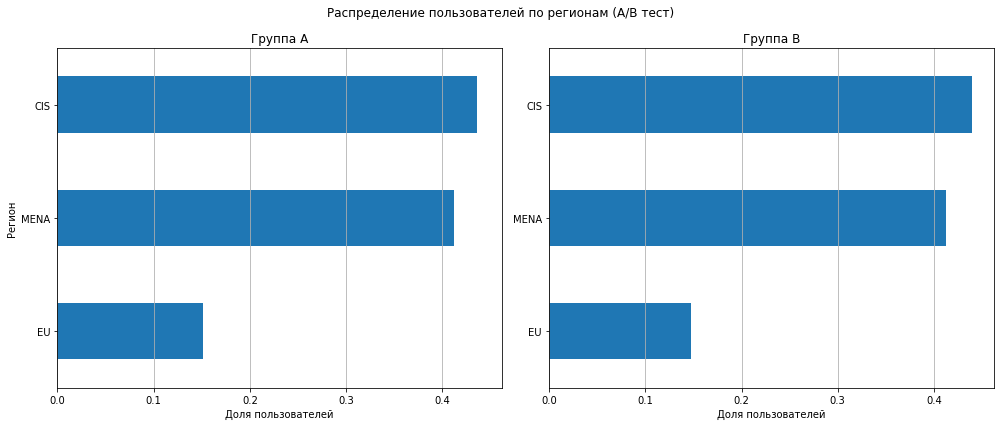

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True)

region_share_A.plot(
    kind='barh',
    ax=axes[0],
    title='Группа A'
)

axes[0].set_xlabel('Доля пользователей')
axes[0].set_ylabel('Регион')
axes[0].grid(axis='x')

region_share_B.plot(
    kind='barh',
    ax=axes[1],
    title='Группа B'
)

axes[1].set_xlabel('Доля пользователей')
axes[1].grid(axis='x')

plt.suptitle('Распределение пользователей по регионам (A/B тест)')
plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

По результатам проверки A/B-тест запущен корректно.

**Распределение пользователей:** группа A — 1 477 чел., группа B — 1 466 чел. Процентная разница — 0.74%, что находится в пределах допустимых отклонений.

**Независимость выборок:** пересечений между группами не обнаружено — 0 пользователей одновременно в обеих группах. Группы полностью изолированы.

**Распределение по устройствам:** расчёт выполнен по уникальным пользователям. Доли типов устройств (Android, iPhone, PC, Mac) в группах A и B визуально совпадают — различия минимальны.

**Распределение по регионам:** расчёт выполнен по уникальным пользователям. Пропорции регионов (CIS, MENA, EU) в обеих группах близки к идентичным.

**Заключение:** тест проводится корректно. Группы сформированы равномерно и независимо. Можно переходить к анализу результатов по завершении эксперимента.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [28]:
# Загружаем данные за весь период теста
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# Создаём флаг успешной сессии: 1 — если просмотрено 4 и более страниц
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

print('Размер датафрейма:', sessions_test.shape)
print('Период теста:', sessions_test['session_date'].min(), '—', sessions_test['session_date'].max())
print('\nГруппы:')
print(sessions_test['test_group'].value_counts())

display(sessions_test.head())

Размер датафрейма: (100005, 12)
Период теста: 2025-10-14 — 2025-11-02

Группы:
B    50454
A    49551
Name: test_group, dtype: int64


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

**Нулевая и альтернативная гипотезы**

**H₀ (нулевая):** Новый алгоритм рекомендаций не влияет на долю успешных первых сессий. Доля пользователей, просмотревших 4 и более страниц в первой сессии, одинакова в группах A и B:

p_A = p_B

**H₁ (альтернативная):** Новый алгоритм рекомендаций увеличивает долю успешных первых сессий. Доля в группе B выше, чем в группе A:

p_B > p_A


**Метрики эксперимента**

**Целевая метрика** — доля первых сессий, в которых пользователь просмотрел 4 и более страниц (good_session = 1). Отражает вовлечённость пользователей в контент с первого взаимодействия с приложением.

**Прокси-метрика** — среднее число просмотренных страниц за первую сессию. Более чувствительна к небольшим изменениям, чем бинарный показатель, и позволяет заметить эффект алгоритма раньше.

**Барьерные метрики** (guardrail metrics) — показатели, которые не должны ухудшиться в ходе эксперимента:

- Доля зарегистрированных пользователей — новый алгоритм не должен снижать конверсию в регистрацию.
- Частота возвращения пользователей в приложение — алгоритм не должен вызывать отток аудитории.
- Количество негативных сигналов (скипы, жалобы на контент) — индикатор качества рекомендаций.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [29]:
# Фильтруем только первые сессии из тестового периода
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# Считаем долю успешных первых сессий по группам
group_metrics = (
    first_sessions_test
    .groupby('test_group')
    .agg(
        total_first_sessions=('good_session', 'count'),
        good_sessions=('good_session', 'sum'),
        good_session_rate=('good_session', 'mean')
    )
    .reset_index()
)

display(group_metrics)

# Извлекаем значения для групп A и B
rate_A = group_metrics.loc[group_metrics['test_group'] == 'A', 'good_session_rate'].values[0]
rate_B = group_metrics.loc[group_metrics['test_group'] == 'B', 'good_session_rate'].values[0]

diff = rate_B - rate_A
relative_diff = diff / rate_A * 100

print(f"\nДоля успешных первых сессий в группе A: {rate_A:.4f} ({rate_A*100:.2f}%)")
print(f"Доля успешных первых сессий в группе B: {rate_B:.4f} ({rate_B*100:.2f}%)")
print(f"Абсолютная разница (B - A): {diff:.4f} ({diff*100:.2f} п.п.)")
print(f"Относительное изменение: {relative_diff:.2f}%")

,test_group,total_first_sessions,good_sessions,good_session_rate
0,A,15162,4787,0.315724
1,B,15416,4851,0.314673



Доля успешных первых сессий в группе A: 0.3157 (31.57%)
Доля успешных первых сессий в группе B: 0.3147 (31.47%)
Абсолютная разница (B - A): -0.0011 (-0.11 п.п.)
Относительное изменение: -0.33%


Доля успешных первых сессий в группе A — 31.57%, в группе B — 31.47%. Разница минимальна: −0.11 п.п. (−0.33%). Визуально группы практически неразличимы, однако для вывода необходим статистический тест.

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [30]:
# Данные для z-теста на пропорции
count_A = int(group_metrics.loc[group_metrics['test_group'] == 'A', 'good_sessions'].values[0])
count_B = int(group_metrics.loc[group_metrics['test_group'] == 'B', 'good_sessions'].values[0])
n_A = int(group_metrics.loc[group_metrics['test_group'] == 'A', 'total_first_sessions'].values[0])
n_B = int(group_metrics.loc[group_metrics['test_group'] == 'B', 'total_first_sessions'].values[0])

# Двусторонний z-тест: H0 — p_A = p_B
stat, p_value = proportions_ztest(
    count=[count_B, count_A],
    nobs=[n_B, n_A],
    alternative='two-sided'
)

print(f"Z-статистика: {stat:.4f}")
print(f"p-value:      {p_value:.4f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha ({alpha}) — нулевая гипотеза ОТВЕРГАЕТСЯ.")
    print("Изменение в доле успешных первых сессий статистически значимо.")
else:
    print(f"p-value ({p_value:.4f}) >= alpha ({alpha}) — нулевая гипотеза НЕ ОТВЕРГАЕТСЯ.")
    print("Изменение в доле успешных первых сессий статистически незначимо.")

Z-статистика: -0.1977
p-value:      0.8433

p-value (0.8433) >= alpha (0.05) — нулевая гипотеза НЕ ОТВЕРГАЕТСЯ.
Изменение в доле успешных первых сессий статистически незначимо.


p-value = 0.8433 >> α = 0.05. Нулевая гипотеза не отвергается. Наблюдаемое различие между группами статистически незначимо и объясняется случайными колебаниями, а не эффектом нового алгоритма.

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**Вывод по результатам A/B-эксперимента**

**Характеристики теста:**

Период проведения: 2025-10-14 — 2025-11-02 (~20 дней)
Контрольная группа A (старый алгоритм): 15 162 первых сессий
Тестовая группа B (новый алгоритм): 15 416 первых сессий
Ключевая метрика: доля первых сессий с ≥ 4 просмотренными страницами
Уровень значимости: α = 0.05

**Влияние нового алгоритма на ключевую метрику:**
Доля успешных первых сессий в группе A составила 31.57%, в группе B — 31.47%. Новый алгоритм не улучшил метрику: разница составила −0.11 п.п. (−0.33%), то есть показатель в тестовой группе оказался незначительно ниже контрольной.

**Статистическая значимость:**
Двусторонний z-тест на пропорции показал Z-статистику −0.1977 и p-value = 0.8433. Это значительно превышает уровень значимости α = 0.05. Нулевая гипотеза не отвергается: различие между группами статистически незначимо и находится в пределах случайных колебаний.

**Рекомендация:**
Новый алгоритм рекомендаций не следует внедрять в приложение. Он не продемонстрировал статистически значимого улучшения ключевой метрики вовлечённости пользователей. Команде разработки рекомендуется проанализировать алгоритм глубже: возможно, эффект существует, но слабее заявленного MDE в 3%, либо алгоритм требует доработки перед повторным тестированием.